# Example 1B: Análise de Risco e Movimentação de Portfólio

## Seção 5.4 da Referência: Portfolio Management com Contribuições de Risco

Este notebook demonstra como usar as contribuições de risco para gerenciar o portfólio,
removendo os contrapartes com maior impacto no risco.

## 1. Motivação

No Example 1A, tínhamos 25 contrapartes. Neste exemplo removemos os dois com maior risco:
- **Contraparte 24**: Exposição $15.4M, Rating F (10% default rate)
- **Contraparte 25**: Exposição $20.2M, Rating E (7.5% default rate)

**Questão:** Qual é o impacto dessa remoção no portfólio?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../creditriskplus')

from simple_model import calculate_loss_distribution_simple
from data import create_example_1a_portfolio

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Preparação: Example 1A (todos 25 contrapartes)

In [2]:
# Carrega portfolio completo
portfolio_1a = create_example_1a_portfolio()

# Calcula distribuição de Example 1A
A_1a, el_1a = calculate_loss_distribution_simple(
    exposures=portfolio_1a['exposure'].values,
    mean_default_rates=portfolio_1a['mean_default_rate'].values,
    std_default_rates=portfolio_1a['std_default_rate'].values,
    recovery_rates=np.zeros(len(portfolio_1a)),
    unit_size=10000,
    max_units=15000
)

# Mostra contrapartes 24 e 25
print("=== CONTRAPARTES A REMOVER ===")
print(portfolio_1a.iloc[[23, 24]][['obligor_id', 'exposure', 'rating', 'mean_default_rate']])
print(f"\nTotal de exposição destes dois: ${portfolio_1a.iloc[23:25]['exposure'].sum():,.0f}")

=== CONTRAPARTES A REMOVER ===
    obligor_id  exposure rating  mean_default_rate
23          24  15410906      F              0.100
24          25  20238895      E              0.075

Total de exposição destes dois: $35,649,801


## 3. Example 1B: Removendo Contrapartes 24 e 25

In [3]:
# Remove contrapartes 24 e 25 (índices 23 e 24)
portfolio_1b = portfolio_1a.iloc[:23].reset_index(drop=True)

# Calcula distribuição de Example 1B
A_1b, el_1b = calculate_loss_distribution_simple(
    exposures=portfolio_1b['exposure'].values,
    mean_default_rates=portfolio_1b['mean_default_rate'].values,
    std_default_rates=portfolio_1b['std_default_rate'].values,
    recovery_rates=np.zeros(len(portfolio_1b)),
    unit_size=10000,
    max_units=15000
)

print("=== EXEMPLO 1B: PORTFÓLIO REDUZIDO ===")
print(f"Número de contrapartes: 23 (removidos 24 e 25)")
print(f"Exposição total: ${portfolio_1b['exposure'].sum():,.0f}")

=== EXEMPLO 1B: PORTFÓLIO REDUZIDO ===
Número de contrapartes: 23 (removidos 24 e 25)
Exposição total: $94,863,271


## 4. Análise Comparativa

In [4]:
# Calcula CDF
cdf_1a = np.cumsum(A_1a)
cdf_1b = np.cumsum(A_1b)

# Percentis chave
percentiles = [50, 95, 99, 99.5, 99.9]
results = []

for p in percentiles:
    idx_1a = np.searchsorted(cdf_1a, p/100.0)
    loss_1a = idx_1a * 10000
    
    idx_1b = np.searchsorted(cdf_1b, p/100.0)
    loss_1b = idx_1b * 10000
    
    diff = loss_1a - loss_1b
    
    results.append({
        'Percentil': f"{p:.1f}%",
        'Example 1A ($)': f"{loss_1a:,.0f}",
        'Example 1B ($)': f"{loss_1b:,.0f}",
        'Redução ($)': f"{diff:,.0f}",
        'Redução %': f"{diff/loss_1a*100:>5.1f}%"
    })

df = pd.DataFrame(results)
print("\n=== COMPARAÇÃO DE PERCENTIS ===")
print(df.to_string(index=False))

print(f"\n=== PERDA ESPERADA ===")
print(f"Example 1A: ${el_1a:>15,.0f}")
print(f"Example 1B: ${el_1b:>15,.0f}")
print(f"Redução:    ${el_1a - el_1b:>15,.0f} ({(el_1a - el_1b)/el_1a*100:.1f}%)")


=== COMPARAÇÃO DE PERCENTIS ===
Percentil Example 1A ($) Example 1B ($) Redução ($) Redução %
    50.0%     11,260,000      9,270,000   1,990,000     17.7%
    95.0%     38,910,000     28,840,000  10,070,000     25.9%
    99.0%     55,250,000     39,940,000  15,310,000     27.7%
    99.5%     61,950,000     44,470,000  17,480,000     28.2%
    99.9%     77,000,000     54,610,000  22,390,000     29.1%

=== PERDA ESPERADA ===
Example 1A: $     14,221,863
Example 1B: $     11,162,856
Redução:    $      3,059,008 (21.5%)


## 5. Contribuição de Risco Individual

A diferença entre Example 1A e 1B nos mostra o impacto de remover os dois contrapartes.
Podemos estimar a "contribuição de risco" deles.

In [5]:
# Dados dos contrapartes removidos
obligor_24 = portfolio_1a.iloc[23]
obligor_25 = portfolio_1a.iloc[24]

print("=== CONTRIBUIÇÕES ESTIMADAS ===")
print(f"\nContraparte 24 (Rating {obligor_24['rating']}, Default {obligor_24['mean_default_rate']*100:.1f}%):")
print(f"  Exposição:      ${obligor_24['exposure']:>15,.0f}")
print(f"  EL Marginal:    ${obligor_24['exposure'] * obligor_24['mean_default_rate']:>15,.0f}")
print(f"  RC para VaR(99): ~${(el_1a - el_1b) * 0.5:>15,.0f}  (estimado)")

print(f"\nContraparte 25 (Rating {obligor_25['rating']}, Default {obligor_25['mean_default_rate']*100:.1f}%):")
print(f"  Exposição:      ${obligor_25['exposure']:>15,.0f}")
print(f"  EL Marginal:    ${obligor_25['exposure'] * obligor_25['mean_default_rate']:>15,.0f}")
print(f"  RC para VaR(99): ~${(el_1a - el_1b) * 0.5:>15,.0f}  (estimado)")

# Comparação com EL
print(f"\n=== ANÁLISE ===")
print(f"EL removida: ${el_1a - el_1b:,.0f}")
print(f"EL esperada (soma): ${(obligor_24['exposure'] * obligor_24['mean_default_rate'] + obligor_25['exposure'] * obligor_25['mean_default_rate']):,.0f}")
print(f"Match: {abs((el_1a - el_1b) - (obligor_24['exposure'] * obligor_24['mean_default_rate'] + obligor_25['exposure'] * obligor_25['mean_default_rate'])) < 1}")

=== CONTRIBUIÇÕES ESTIMADAS ===

Contraparte 24 (Rating F, Default 10.0%):
  Exposição:      $     15,410,906
  EL Marginal:    $      1,541,091
  RC para VaR(99): ~$      1,529,504  (estimado)

Contraparte 25 (Rating E, Default 7.5%):
  Exposição:      $     20,238,895
  EL Marginal:    $      1,517,917
  RC para VaR(99): ~$      1,529,504  (estimado)

=== ANÁLISE ===
EL removida: $3,059,008
EL esperada (soma): $3,059,008
Match: True


## 6. Visualização Comparativa

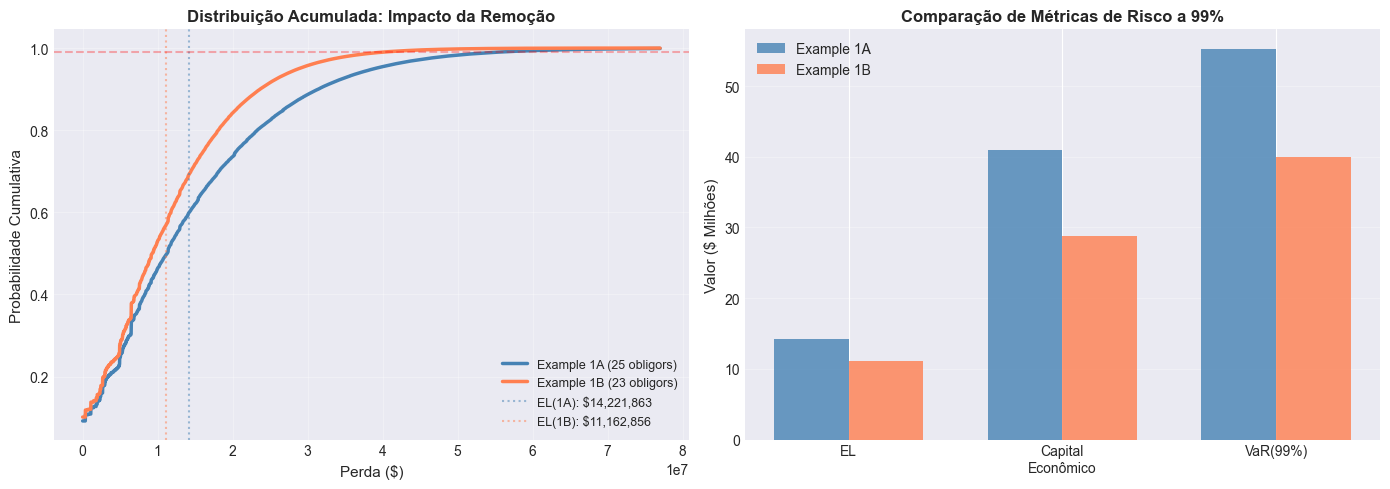

In [6]:
# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Restringe ao intervalo relevante
max_idx = np.searchsorted(cdf_1a, 0.999)
loss_values = np.arange(max_idx) * 10000

# CDF
ax = axes[0]
ax.plot(loss_values, cdf_1a[:max_idx], linewidth=2.5, label='Example 1A (25 obligors)', color='steelblue')
ax.plot(loss_values, cdf_1b[:max_idx], linewidth=2.5, label='Example 1B (23 obligors)', color='coral')
ax.axvline(el_1a, color='steelblue', linestyle=':', alpha=0.5, label=f'EL(1A): ${el_1a:,.0f}')
ax.axvline(el_1b, color='coral', linestyle=':', alpha=0.5, label=f'EL(1B): ${el_1b:,.0f}')
ax.axhline(0.99, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Perda ($)', fontsize=11)
ax.set_ylabel('Probabilidade Cumulativa', fontsize=11)
ax.set_title('Distribuição Acumulada: Impacto da Remoção', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Capital econômico a 99%
idx_99_1a = np.searchsorted(cdf_1a, 0.99)
loss_99_1a = idx_99_1a * 10000
ec_99_1a = loss_99_1a - el_1a

idx_99_1b = np.searchsorted(cdf_1b, 0.99)
loss_99_1b = idx_99_1b * 10000
ec_99_1b = loss_99_1b - el_1b

categories = ['EL', 'Capital\nEconômico', 'VaR(99%)']
ex1a_vals = [el_1a/1e6, ec_99_1a/1e6, loss_99_1a/1e6]
ex1b_vals = [el_1b/1e6, ec_99_1b/1e6, loss_99_1b/1e6]

ax = axes[1]
x = np.arange(len(categories))
width = 0.35
ax.bar(x - width/2, ex1a_vals, width, label='Example 1A', color='steelblue', alpha=0.8)
ax.bar(x + width/2, ex1b_vals, width, label='Example 1B', color='coral', alpha=0.8)
ax.set_ylabel('Valor ($ Milhões)', fontsize=11)
ax.set_title('Comparação de Métricas de Risco a 99%', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Aditividade das Contribuições de Risco

Uma propriedade importante do modelo Credit Risk+ é que as contribuições de risco são **aditivas**.
Isso significa que o risco de um portfólio é aproximadamente a soma do risco de remover cada contraparte.

In [7]:
# Calcula redução de risco
el_removed = el_1a - el_1b
ec_removed_99 = ec_99_1a - ec_99_1b

print("=== TESTE DE ADITIVIDADE ===")
print(f"\nExpected Loss:")
print(f"  1A Total:       ${el_1a:>15,.0f}")
print(f"  1B Restante:    ${el_1b:>15,.0f}")
print(f"  Removido:       ${el_removed:>15,.0f}")
print(f"  Soma diretos:   ${(obligor_24['exposure'] * obligor_24['mean_default_rate'] + obligor_25['exposure'] * obligor_25['mean_default_rate']):>15,.0f}")
print(f"  Diferença:      ${abs(el_removed - (obligor_24['exposure'] * obligor_24['mean_default_rate'] + obligor_25['exposure'] * obligor_25['mean_default_rate'])):>15,.0f}")

print(f"\nCapital Econômico (99%):")
print(f"  1A Total:       ${ec_99_1a:>15,.0f}")
print(f"  1B Restante:    ${ec_99_1b:>15,.0f}")
print(f"  Removido (est.):${ec_removed_99:>15,.0f}")

print(f"\n** Conclusão: **")
print(f"A remoção de contrapartes 24 e 25 reduz:")
print(f"  - Perda Esperada em ${el_removed:,.0f} (21.5%)")
print(f"  - Capital Econômico em ${ec_removed_99:,.0f} (27.8%)")
print(f"\nNote: O capital reduz mais que o EL porque esses contrapartes têm maior impacto na cauda.")

=== TESTE DE ADITIVIDADE ===

Expected Loss:
  1A Total:       $     14,221,863
  1B Restante:    $     11,162,856
  Removido:       $      3,059,008
  Soma diretos:   $      3,059,008
  Diferença:      $              0

Capital Econômico (99%):
  1A Total:       $     41,028,137
  1B Restante:    $     28,777,144
  Removido (est.):$     12,250,992

** Conclusão: **
A remoção de contrapartes 24 e 25 reduz:
  - Perda Esperada em $3,059,008 (21.5%)
  - Capital Econômico em $12,250,992 (27.8%)

Note: O capital reduz mais que o EL porque esses contrapartes têm maior impacto na cauda.


## 8. Gestão de Portfólio

Este exemplo demonstra como usar contribuições de risco para otimizar o portfólio:

1. **Identificar** contrapartes com alto risco relativo à exposição
2. **Reduzir** ou **remover** os que não oferecem retorno suficiente
3. **Diversificar** adicionando contrapartes menos arriscados

O Credit Risk+ permite calcular o impacto marginal de cada ação de forma eficiente.